In [2]:
import pandas as pd
df=pd.read_csv('NewYorkCityTaxiTripDuration.csv',nrows=1500)
df.head()

,id,vendor_id,pickup_datetime,dropoff_datetime,passenger_count,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,store_and_fwd_flag,trip_duration
0,id2875421,2,2016-03-14 17:24:55,2016-03-14 17:32:30,1,-73.982155,40.767937,-73.964630,40.765602,N,455
1,id2377394,1,2016-06-12 00:43:35,2016-06-12 00:54:38,1,-73.980415,40.738564,-73.999481,40.731152,N,663
2,id3858529,2,2016-01-19 11:35:24,2016-01-19 12:10:48,1,-73.979027,40.763939,-74.005333,40.710087,N,2124
3,id3504673,2,2016-04-06 19:32:31,2016-04-06 19:39:40,1,-74.010040,40.719971,-74.012268,40.706718,N,429
4,id2181028,2,2016-03-26 13:30:55,2016-03-26 13:38:10,1,-73.973053,40.793209,-73.972923,40.782520,N,435


In [3]:
x=df[['pickup_longitude','pickup_latitude']]
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
x_scaled=sc.fit_transform(x)

In [4]:
from sklearn.cluster._dbscan import DBSCAN
from sklearn.metrics import silhouette_score
eps=[0.2,0.3,0.5]
for ep in eps:
    print("DBSCAN for eps: ",ep)
    db=DBSCAN(eps=ep,min_samples=5)
    labels=db.fit_predict(x_scaled) #it is labels as it contains both clusters and noise(-1)
    unq_labels=set(labels)
    n_clusters=len(unq_labels)-(1 if -1 in unq_labels else 0)
    noise_points=list(labels).count(-1)
    noise_ratio=noise_points/len(labels)
    print("no. of clusters: ",n_clusters)
    print("noise points ratio: ",round(noise_ratio,3))
    if n_clusters>=2:
        mask=labels!=-1
        # print(mask)
        print("silhouette score: ",round(silhouette_score(x_scaled[mask],labels[mask]),3))

DBSCAN for eps:  0.2
no. of clusters:  5
noise points ratio:  0.031
silhouette score:  0.326
DBSCAN for eps:  0.3
no. of clusters:  4
noise points ratio:  0.022
silhouette score:  0.418
DBSCAN for eps:  0.5
no. of clusters:  5
noise points ratio:  0.008
silhouette score:  0.337


In [5]:
db=DBSCAN(eps=0.4,min_samples=5)
clusters=db.fit_predict(x_scaled)

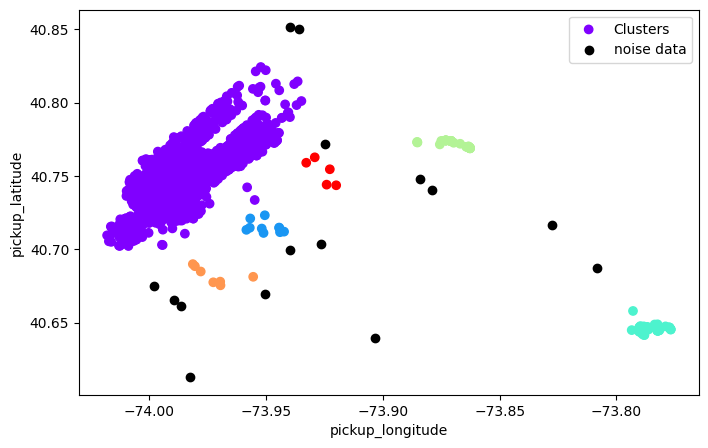

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.scatter(x.iloc[clusters!=-1,0],x.iloc[clusters!=-1,1],c=clusters[clusters!=-1],cmap='rainbow',label='Clusters')
plt.scatter(x.iloc[clusters==-1,0],x.iloc[clusters==-1,1],c='black',label='noise data')
plt.xlabel('pickup_longitude')
plt.ylabel('pickup_latitude')
plt.legend()
plt.show()